## 1. Carregamento do Dataset (KaggleHub)


In [1]:
!pip install kagglehub[pandas-datasets]


In [2]:
from google.colab import files
files.upload()  # Selecione o kaggle.json aqui


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ojaooo","key":"32876921ef0ef89f7d727fa5f7179bff"}'}

In [3]:
import os
import zipfile

# Mover o kaggle.json para a pasta certa
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Use o caminho do CSV dentro do dataset
file_path = "US_Accidents_March23.csv"  # Caminho real do arquivo no Kaggle

# Carrega o dataset direto do Kaggle
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sobhanmoosavi/us-accidents",
  file_path,
  pandas_kwargs={"nrows": 5000}  # Aqui limitamos a 5.000 linhas!
)

print(df.head())


<ipython-input-4-689a2260c9e4>:8: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 653M/653M [00:04<00:00, 152MB/s]

Extracting zip of US_Accidents_March23.csv...


    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

## 2. Pré-processamento dos Dados

In [10]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Supondo que seu DataFrame original já esteja carregado na variável df:
df = df[['Start_Time', 'Temperature(F)', 'Weather_Condition', 'Visibility(mi)', 'Severity']]

# Criar coluna de hora do dia
df['hora'] = pd.to_datetime(df['Start_Time']).dt.hour

# Converter temperatura de Fahrenheit para Celsius
df['temperatura'] = (df['Temperature(F)'] - 32) * 5/9

# Criar coluna binária "acidente" (1 se Severity >= 2)
df['acidente'] = df['Severity'].apply(lambda x: 1 if x >= 2 else 0)

# Renomear e selecionar colunas finais
df = df.rename(columns={
    'Weather_Condition': 'condicao_climatica',
    'Visibility(mi)': 'visibilidade'
})
df = df[['hora', 'temperatura', 'condicao_climatica', 'visibilidade', 'acidente']]

# Remover linhas com valores nulos
df.dropna(inplace=True)

# Normalizar colunas numéricas
scaler = MinMaxScaler()
df[['hora', 'temperatura', 'visibilidade']] = scaler.fit_transform(df[['hora', 'temperatura', 'visibilidade']])

# One-Hot Encoding para condição climática
df = pd.get_dummies(df, columns=['condicao_climatica'], prefix='clima')


## 3. Preparação para o Treinamento

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['acidente'])
y = df['acidente']


## 4. Treinamento do Modelo

In [13]:
# Separação treino/teste
from sklearn.model_selection import train_test_split

X = df.drop(columns=['acidente'])
y = df['acidente']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9727 - loss: 0.4787 - val_accuracy: 0.9975 - val_loss: 0.0858
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9994 - loss: 0.0452 - val_accuracy: 0.9975 - val_loss: 0.0193
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9995 - loss: 0.0062 - val_accuracy: 0.9975 - val_loss: 0.0198
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0047 - val_accuracy: 0.9975 - val_loss: 0.0215
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.9975 - val_loss: 0.0224
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9998 - loss: 0.0021 - val_accuracy: 0.9975 - val_loss: 0.0231
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9975 - val_loss: 0.0236
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9987 - loss: 0.0076 - val_accuracy: 0.9975 - val_loss:

##5. Avaliação e Visualização dos Resultados

In [14]:
# Avaliar o modelo no conjunto de teste
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Acurácia no conjunto de teste: {accuracy:.4f}')


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 4.9613e-04 
Acurácia no conjunto de teste: 1.0000


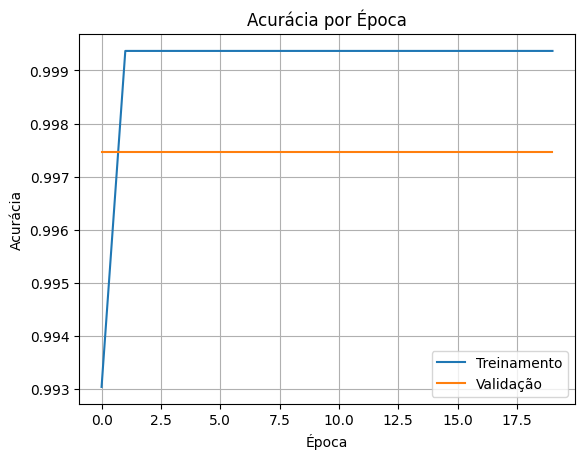

In [15]:
import matplotlib.pyplot as plt

# Plotar curva de acurácia
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()


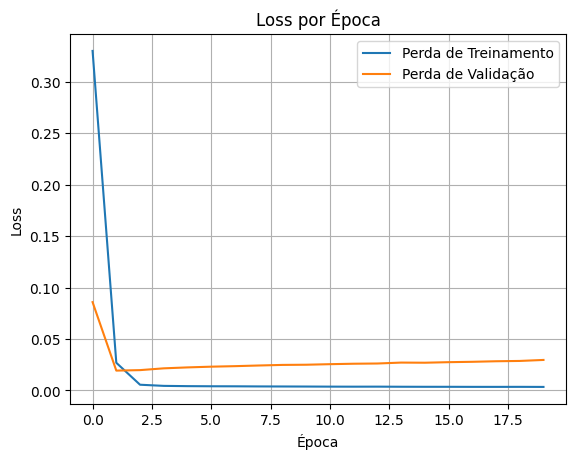

In [16]:
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.title('Loss por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
